<a href="https://colab.research.google.com/github/Naini-Diwan/Sun-Photometer-Data-Analysis/blob/main/SunPhotometer_Langley_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Langley Analysis for Atmospheric Optical Depth (AOD)
This notebook demonstrates how to perform Langley analysis on atmospheric data to determine Aerosol Optical Depth (AOD) using collected irradiance measurements and calculated air mass values.

Copyright 2026 [Naini Diwan](https://naini-diwan.github.io/Hello-Naini/), Licensed under the MIT License.

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/drive/1hzQPuYqKUQazBmSOxVHng3Zn7UKsIPo9?usp=drive_link"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/Naini-Diwan/Sun-Photometer-Data-Analysis/blob/main/SunPhotometer_Langley_Analysis.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://drive.google.com/uc?export=download&id=1hzQPuYqKUQazBmSOxVHng3Zn7UKsIPo9"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

Import essential libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import datetime

#Loading Data

As an example, one may try uploading the [SunPhotometer-Data.txt](https://github.com/Naini-Diwan/Sun-Photometer-Data-Analysis/blob/main/SunPhotometer-Data.txt) file which is present in the same Github repository as this notebook, and contains sample readings of the sun photometer for 6 days, taken by me 4-times-each-day.

In [9]:
# Loading dataframe 'df'
try:
    if 'df' not in locals():
        raise NameError
except NameError:
    with open('SP_10_11_12_15_16_17.txt', 'r') as f:
        content = f.read()
    data_lines = []
    for line in content.split('\n'):
        if not line.strip() or 'AOT' in line or 'AVG' in line: continue
        parts = line.split()
        if len(parts) >= 6:
            try:
                dt = datetime.datetime.strptime(f"{parts[0]} {parts[1]}", "%d/%m/%y %H:%M:%S")
                data_lines.append({
                    'datetime': dt,
                    'V500': float(parts[2]), 'V400': float(parts[3]),
                    'V870': float(parts[4]), 'V1020': float(parts[5])
                })
            except: pass
    df = pd.DataFrame(data_lines)

# Preprocessing the data

In [10]:
# Function to calculate Air Mass
def calculate_air_mass(date_time, lat, lon):
    doy = date_time.timetuple().tm_yday
    hour = date_time.hour + date_time.minute/60.0 + date_time.second/3600.0
    utc_hour = hour - 5.5
    if utc_hour < 0:
        utc_hour += 24
        doy_utc = doy - 1
    else:
        doy_utc = doy

    gamma = 2 * np.pi * (doy_utc - 1) / 365.0
    delta = 0.006918 - 0.399912*np.cos(gamma) + 0.070257*np.sin(gamma) \
            - 0.006758*np.cos(2*gamma) + 0.000907*np.sin(2*gamma) \
            - 0.00002*np.cos(3*gamma) + 0.00002*np.sin(3*gamma)

    eot = 229.18 * (0.000075 + 0.001868*np.cos(gamma) - 0.032077*np.sin(gamma) \
          - 0.014615*np.cos(2*gamma) - 0.040849*np.sin(2*gamma))

    solar_time_hour = utc_hour + lon/15.0 + eot/60.0
    h = 15 * (solar_time_hour - 12)
    h_rad = np.radians(h)
    lat_rad = np.radians(lat)

    cos_theta = np.sin(lat_rad) * np.sin(delta) + np.cos(lat_rad) * np.cos(delta) * np.cos(h_rad)
    cos_theta = np.clip(cos_theta, -1, 1)
    theta_rad = np.arccos(cos_theta)
    theta_deg = np.degrees(theta_rad)

    if theta_deg < 90:
        m = 1.0 / (np.cos(theta_rad) + 0.50572 * (96.07995 - theta_deg)**(-1.6364))
    else:
        m = np.nan
    return m

In [11]:
latitude = 23.0258
longitude = 72.5873
altitude_m = 27.00

In [12]:
# Calculate Air Mass and Log Values for all data points
df['Air_Mass'] = df['datetime'].apply(lambda x: calculate_air_mass(x, latitude, longitude))
df['ln_V500'] = np.log(df['V500'].replace(0, np.nan))
df['ln_V400'] = np.log(df['V400'].replace(0, np.nan))
df['ln_V870'] = np.log(df['V870'].replace(0, np.nan))
df['ln_V1020'] = np.log(df['V1020'].replace(0, np.nan))

In [13]:
# Remove NaN and very low signals
valid_df = df.dropna(subset=['Air_Mass', 'ln_V500', 'ln_V400', 'ln_V870', 'ln_V1020'])

# Filter the air mass values
# Typically values are best obtained between AM 2 and 6 to avoid noon variance and horizon effects
valid_df = valid_df[valid_df['Air_Mass'] < 10]

# Perform Langley Analysis

Set the lat-long and altitute (in m) of the sunphotometer from ground level

In [14]:
# Define Groups, for instance:
# A: Dec 10, 11, 12
group_a = valid_df[valid_df['datetime'].dt.day.isin([10, 11, 12])]
# B: Dec 15, 16, 17
group_b = valid_df[valid_df['datetime'].dt.day.isin([15, 16, 17])]
# C: entire dataset
group_c = valid_df

In [15]:
def perform_langley_regression(data, channel_col):
    # Linear regression: ln(V) = slope * m + intercept
    # Slope = -Total_Optical_Depth
    # Intercept = ln(V0)
    if len(data) < 2: return None
    res = stats.linregress(data['Air_Mass'], data[channel_col])
    return res

results = {}
channels = {'500nm': 'ln_V500', '400nm': 'ln_V400', '870nm': 'ln_V870', '1020nm': 'ln_V1020'}

In [21]:
# Calculate stats
stats_list = []
for group_name, group_data in [('A (Dec 10-12)', group_a), ('B (Dec 15-17)', group_b), ('C (All Dates)', group_c)]:
    for ch_name, ch_col in channels.items():
        reg = perform_langley_regression(group_data, ch_col)
        if reg:
            stats_list.append({
                'Group': group_name,
                'Channel': ch_name,
                'Slope (-tau)': reg.slope,
                'Intercept (lnV0)': reg.intercept,
                'R_squared': reg.rvalue**2,
                'AOD_Total': -reg.slope,
                'Count': len(group_data)
            })

stats_df = pd.DataFrame(stats_list)
print("Langley Regression Statistics:\n")
display(stats_df)

Langley Regression Statistics:



,Group,Channel,Slope (-tau),Intercept (lnV0),R_squared,AOD_Total,Count
0,A (Dec 10-12),500nm,0.079859,6.170467,0.002709,-0.079859,400
1,A (Dec 10-12),400nm,-0.642276,6.139038,0.801111,0.642276,400
2,A (Dec 10-12),870nm,-0.134003,6.719029,0.256373,0.134003,400
3,A (Dec 10-12),1020nm,-0.379915,5.784068,0.650475,0.379915,400
4,B (Dec 15-17),500nm,-0.055580,5.584159,0.005247,0.055580,507
5,B (Dec 15-17),400nm,-0.527914,5.760127,0.953008,0.527914,507
6,B (Dec 15-17),870nm,-0.166825,6.751413,0.744974,0.166825,507
7,B (Dec 15-17),1020nm,-0.446803,5.788510,0.915252,0.446803,507
8,C (All Dates),500nm,-0.117659,6.128467,0.018766,0.117659,907
9,C (All Dates),400nm,-0.549720,5.883326,0.932757,0.549720,907


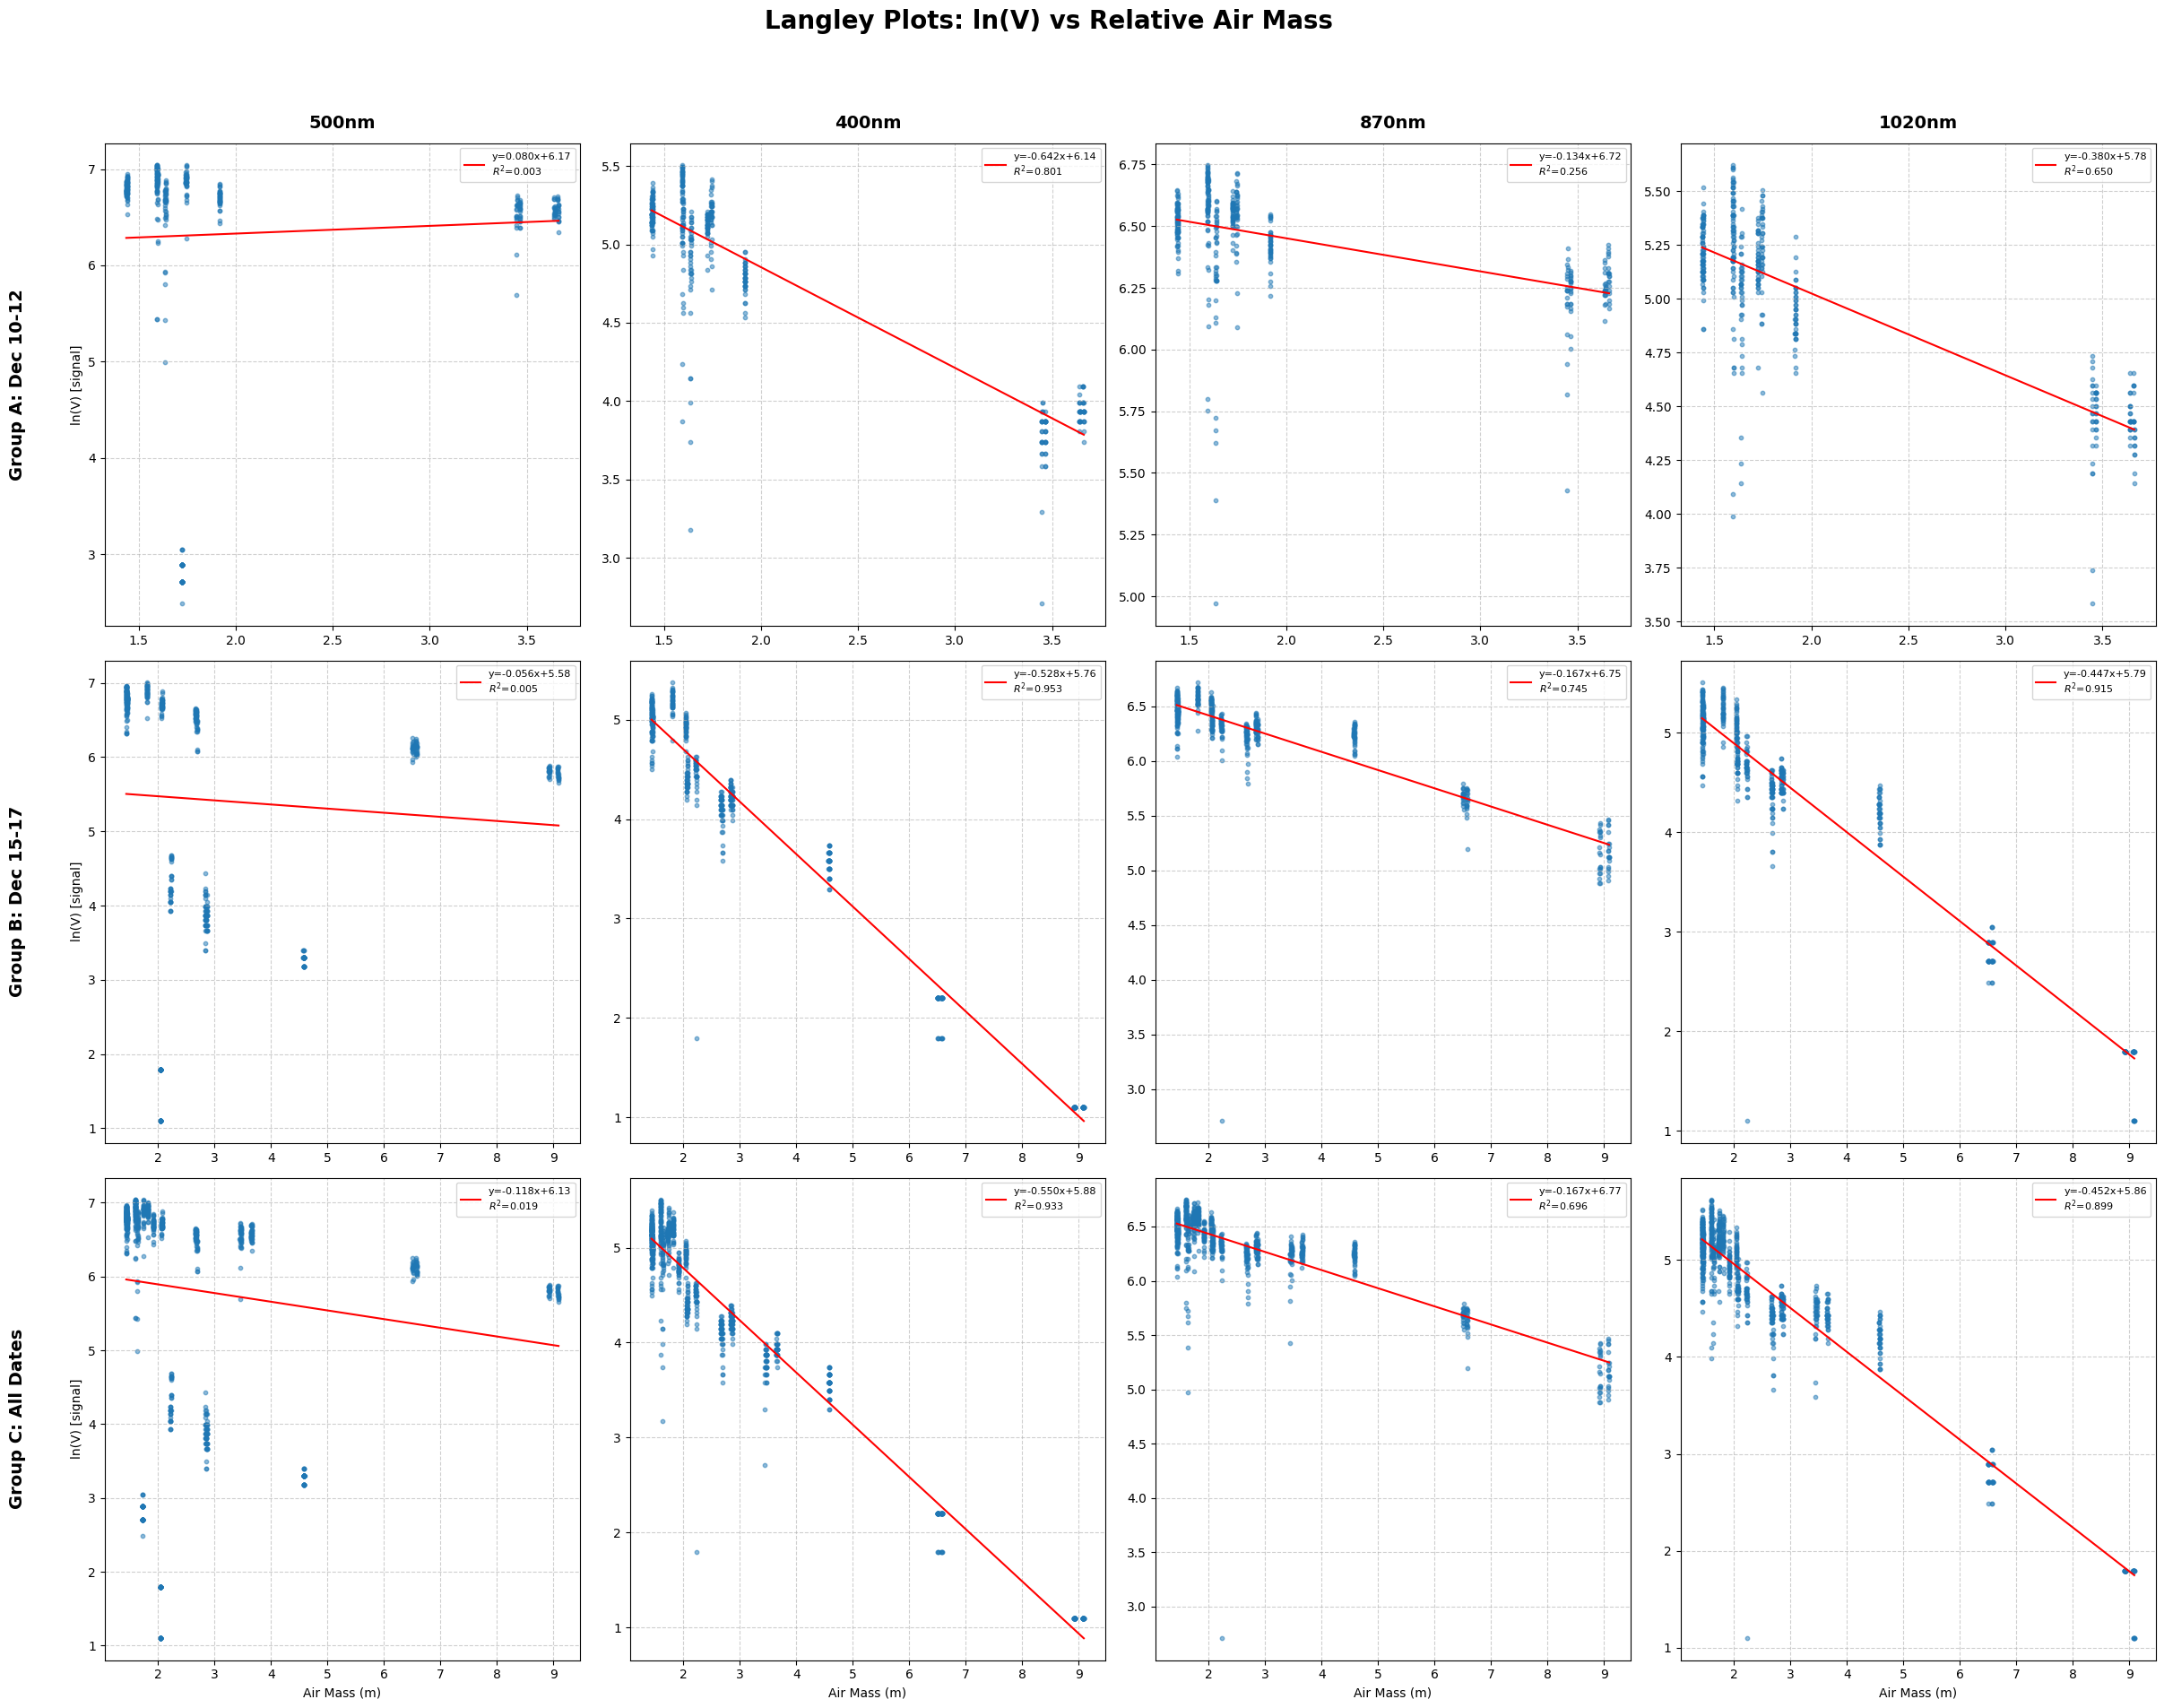

In [25]:
# Plotting
fig, axes = plt.subplots(3, 4, figsize=(25, 20))
fig.suptitle('Langley Plots: ln(V) vs Relative Air Mass', fontsize=20, fontweight='bold')
groups_plot = [('Group A: Dec 10-12', group_a), ('Group B: Dec 15-17', group_b), ('Group C: All Dates', group_c)]
channel_keys = list(channels.keys())

for i, (grp_name, grp_data) in enumerate(groups_plot):
    for j, ch in enumerate(channel_keys):
        ax = axes[i, j]
        col = channels[ch]

        # Scatter
        ax.scatter(grp_data['Air_Mass'], grp_data[col], alpha=0.5, s=10)

        # Regression Line
        reg = perform_langley_regression(grp_data, col)
        if reg:
            x_vals = np.array([grp_data['Air_Mass'].min(), grp_data['Air_Mass'].max()])
            y_vals = reg.slope * x_vals + reg.intercept
            ax.plot(x_vals, y_vals, 'r-', label=f'y={reg.slope:.3f}x+{reg.intercept:.2f}\n$R^2$={reg.rvalue**2:.3f}')
            ax.legend(fontsize=8)

        # Ticks on every subplot
        ax.tick_params(axis='both', which='both', labelbottom=True, labelleft=True)

        if i == 2:
            ax.set_xlabel('Air Mass (m)')
        if j == 0:
            ax.set_ylabel('ln(V) [signal]')

        # Column headers on top row only
        if i == 0:
            ax.set_title(ch, fontsize=14, fontweight='bold', pad=12)

        ax.grid(True, linestyle='--', alpha=0.6)

    # Row headers on left-most column, outside the axes
    axes[i, 0].annotate(
        grp_name,
        xy=(0, 0.5), xycoords='axes fraction',
        xytext=(-70, 0), textcoords='offset points',
        fontsize=14, fontweight='bold',
        ha='center', va='center', rotation=90
    )

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])

# Save the plot in colab environment
plt.savefig('Langley_Plots.png', dpi=150, bbox_inches='tight')